# HCP Subnetwork Analysis

In [9]:
import pickle
with open('/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl', 'rb') as f:
    data = pickle.load(f)

data['185139'].keys()

dict_keys(['BOLD', 'gender', 'FC', 'age'])

Subject 185139 — gender: F, age: 31 yrs
BOLD shape: (379, 1190)  |  TR=0.72s
Window: 14 TRs = 10.1 s  |  85 windows


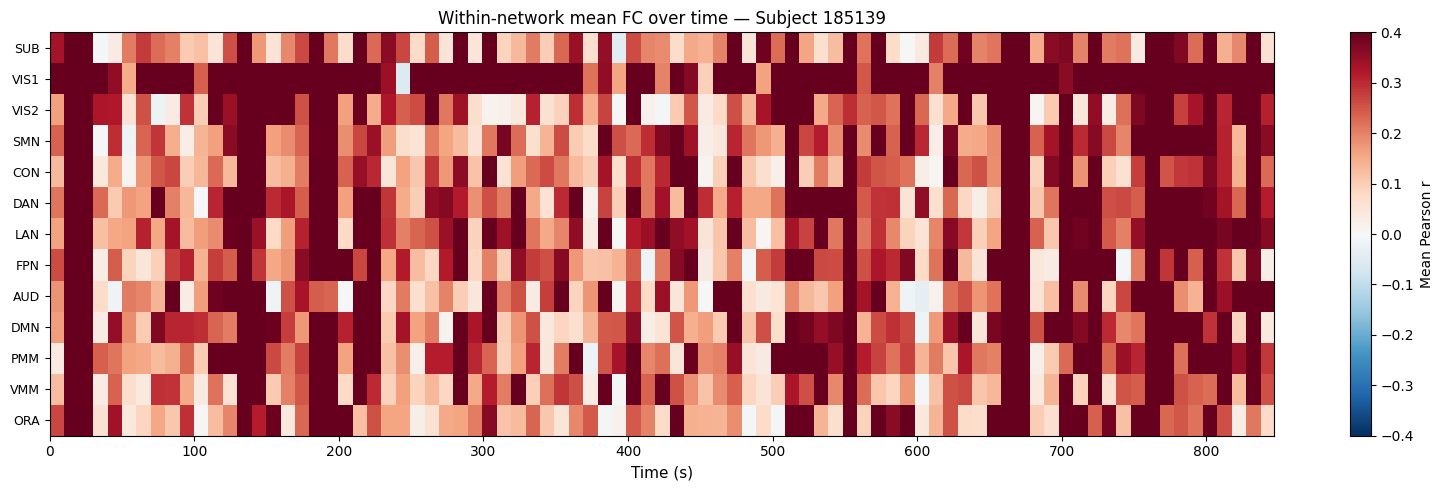

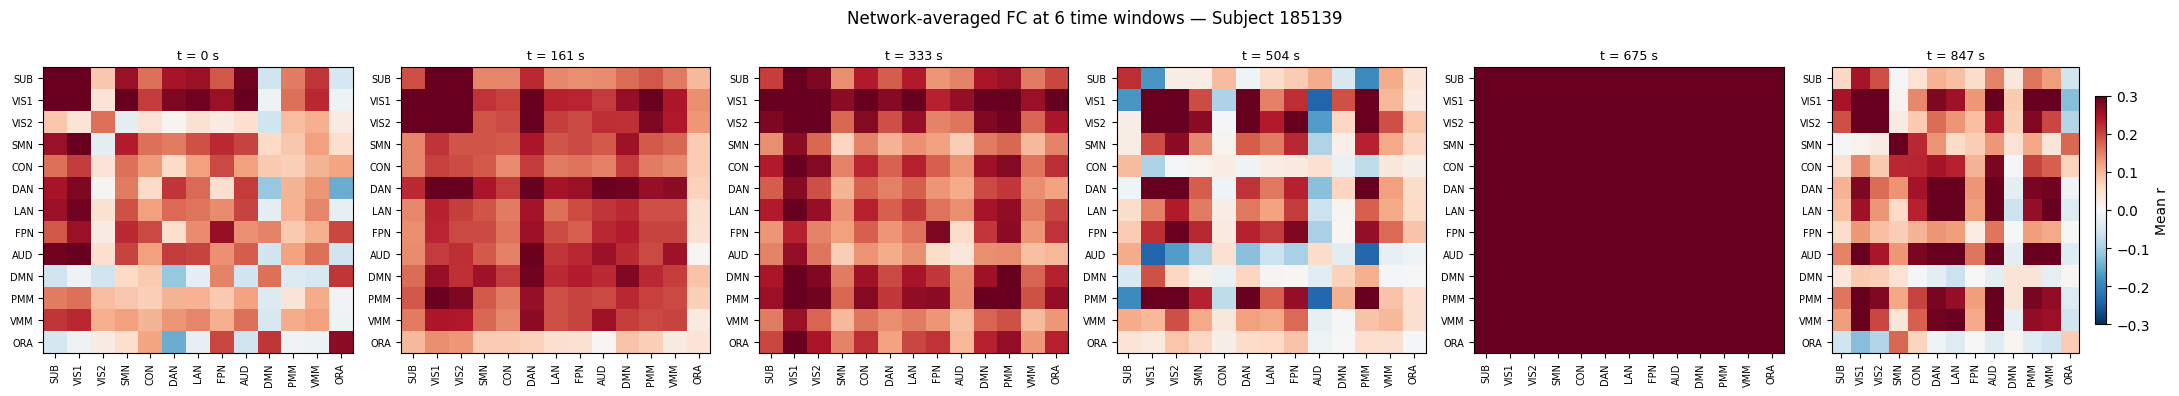

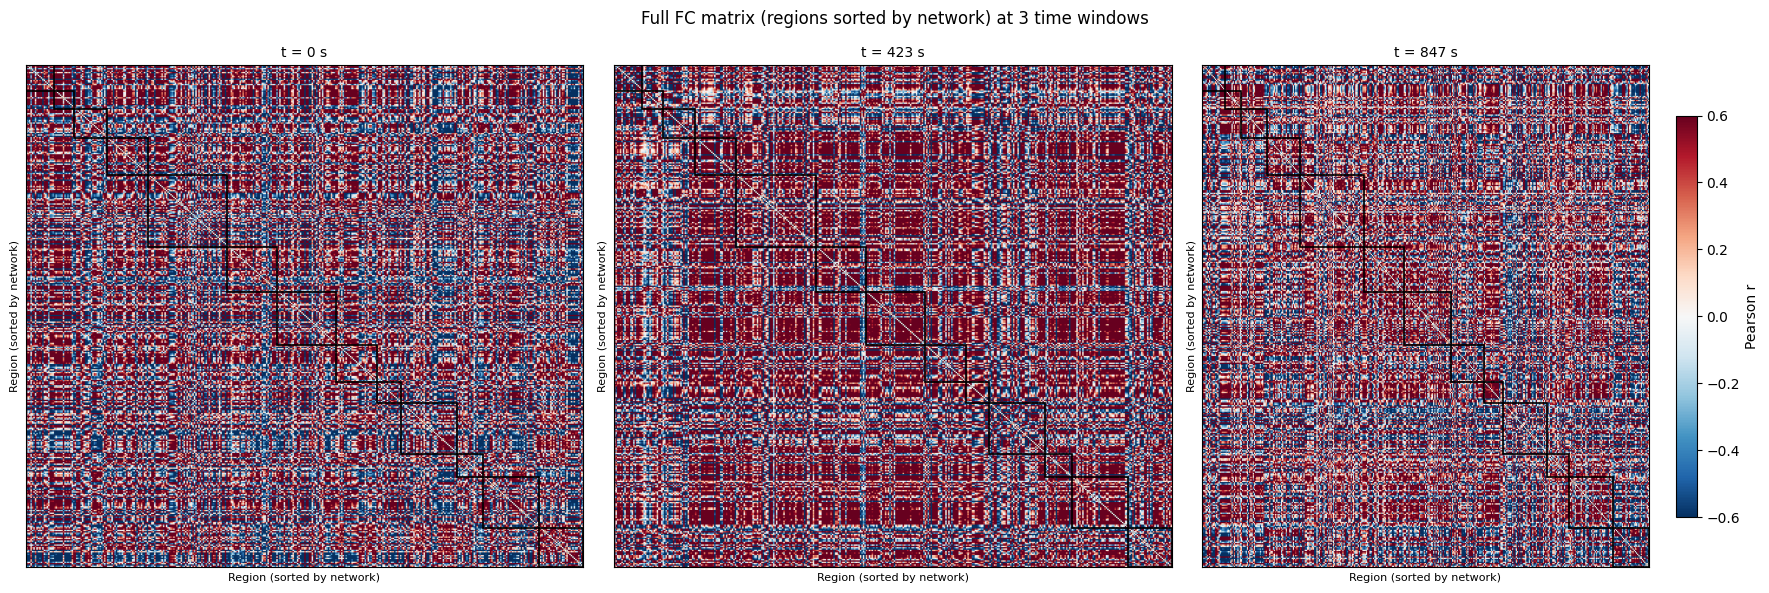

In [1]:
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Load data ────────────────────────────────────────────────────────────────
with open('/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl', 'rb') as f:
    data = pickle.load(f)

subj      = data['185139']
bold      = subj['BOLD']          # (379, 1190)  rows=regions, cols=timepoints
TR        = 0.72                   # HCP resting-state TR in seconds

glasser = pd.read_csv(
    '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/glasser_atlas_netwroks/Glasser360_Subcortical_ColeAnticevic_Networks.csv'
)

print(f"Subject 185139 — gender: {subj['gender']}, age: {subj['age']} yrs")
print(f"BOLD shape: {bold.shape}  |  TR={TR}s")

# ── Window parameters ────────────────────────────────────────────────────────
WIN_SEC  = 10
win_len  = int(round(WIN_SEC / TR))          # 14 TRs
n_tp     = bold.shape[1]
n_win    = n_tp // win_len
t_axis   = np.arange(n_win) * win_len * TR   # centre time in seconds

print(f"Window: {win_len} TRs = {win_len * TR:.1f} s  |  {n_win} windows")

# ── Clean and Standardize Network Info ───────────────────────────────────────
# Fill any missing IDs or abbreviations explicitly so they cluster together naturally
glasser['Network_ID'] = glasser['Network_ID'].fillna(-1)  # Group missing IDs as -1
glasser['Network_Abbr'] = glasser['Network_Abbr'].fillna('Unknown')

# ── Sort regions by network ──────────────────────────────────────────────────
# Putting -1/Unknown at the end by tracking valid IDs first, or letting standard sort handle it
glasser_sorted  = glasser.sort_values(['Network_ID', 'Parcel_Index']).reset_index(drop=True)
region_order    = glasser_sorted['Parcel_Index'].values - 1   # 0-based indices into BOLD
net_ids_sorted  = glasser_sorted['Network_ID'].values

bold_sorted = bold[region_order, :]   # (379, 1190)  reordered by network

# Unique networks in order
unique_net_ids = list(dict.fromkeys(net_ids_sorted))          # preserves first-seen order

# Map IDs to Abbreviations reliably
id_to_abbr = glasser_sorted.set_index('Network_ID')['Network_Abbr'].to_dict()
net_abbrs  = [id_to_abbr.get(nid, 'Unknown') for nid in unique_net_ids]

n_nets     = len(unique_net_ids)

# Network boundary positions (for drawing boxes on full FC)
boundaries = []
pos = 0
for nid in unique_net_ids:
    size = (net_ids_sorted == nid).sum()
    boundaries.append((pos, size))
    pos += size

# ── Compute per-window network-averaged FC ───────────────────────────────────
net_fc = np.full((n_win, n_nets, n_nets), np.nan)

for w in range(n_win):
    ts = bold_sorted[:, w * win_len : (w + 1) * win_len]   # (379, 14)
    fc = np.corrcoef(ts)                                     # (379, 379)
    np.fill_diagonal(fc, np.nan)

    for i, ni in enumerate(unique_net_ids):
        mi = net_ids_sorted == ni
        for j, nj in enumerate(unique_net_ids):
            mj = net_ids_sorted == nj
            block = fc[np.ix_(mi, mj)]
            if i == j:
                if block.size > 1: # Avoid single-region network upper-triangle crash
                    triu = block[np.triu_indices(block.shape[0], k=1)]
                    net_fc[w, i, j] = np.nanmean(triu) if triu.size > 0 else np.nanmean(block)
                else:
                    net_fc[w, i, j] = np.nanmean(block)
            else:
                net_fc[w, i, j] = np.nanmean(block)

# ── Plot 1: within-network FC over time ──────────────────────────────────────
within_fc = net_fc[:, np.arange(n_nets), np.arange(n_nets)]   # (n_win, n_nets)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(within_fc.T, aspect='auto', cmap='RdBu_r',
               vmin=-0.4, vmax=0.4,
               extent=[t_axis[0], t_axis[-1], n_nets - 0.5, -0.5])
ax.set_yticks(range(n_nets))
ax.set_yticklabels(net_abbrs, fontsize=9)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_title('Within-network mean FC over time — Subject 185139', fontsize=12)
plt.colorbar(im, ax=ax, label='Mean Pearson r')
plt.tight_layout()
plt.show()

# ── Plot 2: network-averaged FC matrices at 6 time points ────────────────────
n_show   = 6
show_idx = np.linspace(0, n_win - 1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(22, 4))
fig.suptitle('Network-averaged FC at 6 time windows — Subject 185139', fontsize=12)
for ax, w in zip(axes, show_idx):
    im = ax.imshow(net_fc[w], cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
    ax.set_xticks(range(n_nets)); ax.set_xticklabels(net_abbrs, rotation=90, fontsize=7)
    ax.set_yticks(range(n_nets)); ax.set_yticklabels(net_abbrs, fontsize=7)
    ax.set_title(f't = {t_axis[w]:.0f} s', fontsize=9)
plt.colorbar(im, ax=axes[-1], label='Mean r', shrink=0.8)
plt.tight_layout()
plt.show()

# ── Plot 3: full 379×379 FC at 3 time points, sorted by network ──────────────
n_show3  = 3
show_idx3 = np.linspace(0, n_win - 1, n_show3, dtype=int)

fig, axes = plt.subplots(1, n_show3, figsize=(18, 6))
fig.suptitle('Full FC matrix (regions sorted by network) at 3 time windows', fontsize=12)

for ax, w in zip(axes, show_idx3):
    ts = bold_sorted[:, w * win_len : (w + 1) * win_len]
    fc = np.corrcoef(ts)
    np.fill_diagonal(fc, np.nan)

    im = ax.imshow(fc, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
    ax.set_title(f't = {t_axis[w]:.0f} s', fontsize=10)
    ax.set_xlabel('Region (sorted by network)', fontsize=8)
    ax.set_ylabel('Region (sorted by network)', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

    # Draw network boundary lines
    for start, size in boundaries:
        rect = mpatches.Rectangle(
            (start - 0.5, start - 0.5), size, size,
            linewidth=1.2, edgecolor='black', facecolor='none'
        )
        ax.add_patch(rect)

plt.colorbar(im, ax=axes[-1], label='Pearson r', shrink=0.8)
plt.tight_layout()
plt.show()